In [1]:
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

from sentence_transformers import SentenceTransformer
import plotly.express as px


In [2]:
from recsys.data.loaders import load_movielens
from recsys.utils.colab import get_data_path
DATA_PATH = get_data_path()
ratings, movies = load_movielens(data_dir=DATA_PATH)
ratings.head()

,userId,movieId,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [3]:
# Keep ratings/movies loaded from load_movielens in Cell 2
print(ratings.head())
print(f"ratings shape: {ratings.shape}")
print(movies.head())
print(f"movies shape: {movies.shape}")

   userId  movieId  rating  timestamp
0     196      242       3  881250949
1     186      302       3  891717742
2      22      377       1  878887116
3     244       51       2  880606923
4     166      346       1  886397596
ratings shape: (100000, 4)
   movieId              title release_date  video_release_date  \
0        1   Toy Story (1995)  01-Jan-1995                 NaN   
1        2   GoldenEye (1995)  01-Jan-1995                 NaN   
2        3  Four Rooms (1995)  01-Jan-1995                 NaN   
3        4  Get Shorty (1995)  01-Jan-1995                 NaN   
4        5     Copycat (1995)  01-Jan-1995                 NaN   

                                            IMDb_URL  unknown  Action  \
0  http://us.imdb.com/M/title-exact?Toy%20Story%2...        0       0   
1  http://us.imdb.com/M/title-exact?GoldenEye%20(...        0       1   
2  http://us.imdb.com/M/title-exact?Four%20Rooms%...        0       0   
3  http://us.imdb.com/M/title-exact?Get%20Shorty%...    

In [4]:
#Listing 2.7: Computing popularity scores                                               . 
movie_counts = ratings['movieId'].value_counts()
max_count = movie_counts.max()

popularity_scores = {
    int(mid): float(count / max_count)
    for mid, count in movie_counts.items()
}

print(f"Most popular movies:")
for movie_id in movie_counts.head(5).index:
    title = movies[movies['movieId'] == movie_id]['title'].values[0]
    pop_score = popularity_scores[movie_id]
    count = movie_counts[movie_id]
    print(f"  {title}: {pop_score:.3f} ({count:,} ratings)")

#A Count ratings per movie 
#B Normalize by max count to get 0-1 range 
#C Display the most popular movies


Most popular movies:
  Star Wars (1977): 1.000 (583 ratings)
  Contact (1997): 0.873 (509 ratings)
  Fargo (1996): 0.871 (508 ratings)
  Return of the Jedi (1983): 0.870 (507 ratings)
  Liar Liar (1997): 0.832 (485 ratings)


In [5]:
from recsys.fourstage_recsys.retrieval.file_based_retrieval import FileBasedRetrieval
from recsys.fourstage_recsys.recsys_context import RecommendationContext
from recsys.fourstage_recsys.item_context import ScoredItem

from typing import List, Optional
import pandas as pd

class PopularityRetrieval(FileBasedRetrieval):

  def _prepare(self):
    item_col = "movieId" if "movieId" in self.interactions_df.columns else "movie_id"
    if item_col not in self.interactions_df.columns:
      raise ValueError("Interactions data must include 'movieId' or 'movie_id'.")

    item_counts = self.interactions_df[item_col].value_counts()
    max_count = item_counts.max()
    self.popularity_scores = {
      str(item_id): float(count / max_count)
      for item_id, count in item_counts.items()
    }

  def retrieve(self, context: RecommendationContext) -> List[ScoredItem]:
    candidates = set()

    if not candidates:
      candidates = set(self.popularity_scores.keys())

    sorted_candidates = sorted(
      candidates,
      key=lambda x: self.popularity_scores.get(x, 0.0),
      reverse=True
    )

    return [
      ScoredItem(
        item_id=item_id,
        score={"popularity": self.popularity_scores.get(item_id, 0.0)}
      )
      for item_id in sorted_candidates[:1000]
    ]


In [6]:
def create_context_with_history(
  interactions_df: pd.DataFrame,
  user_id: Optional[str] = None,
  item_id: Optional[str] = None,
  k: int = 10
) -> RecommendationContext:
  user_col = "userId" if "userId" in interactions_df.columns else "user_id"
  item_col = "movieId" if "movieId" in interactions_df.columns else "movie_id"

  user_history = set()
  if user_id and user_col in interactions_df.columns and item_col in interactions_df.columns:
    user_items = interactions_df[
      interactions_df[user_col].astype(str) == str(user_id)
    ][item_col].unique()
    user_history = set(str(x) for x in user_items)

  return RecommendationContext(
    user_id=str(user_id) if user_id is not None else None,
    item_id=item_id,
    k=k,
    metadata={"user_history": sorted(user_history)}
  )

In [7]:
from recsys.fourstage_recsys.item_context import ScoredItem
from recsys.fourstage_recsys.recsys_context import RecommendationContext

class PassThroughScorer:
  def __init__(self, retrieval: PopularityRetrieval):
    self.retrieval = retrieval

  def score(
    self,
    candidates: List[ScoredItem],
    context: RecommendationContext
  ) -> List[ScoredItem]:
    return candidates

class HistoryFilter:
  def filter(
    self,
    scored_items: List[ScoredItem],
    context: RecommendationContext
  ) -> List[ScoredItem]:
    user_history = set(str(x) for x in context.metadata.get("user_history", []))
    return [item for item in scored_items if item.item_id not in user_history]

class TopKRanker:
  def rank(
    self,
    filtered_items: List[ScoredItem],
    context: RecommendationContext
  ) -> List[ScoredItem]:
    return sorted(
      filtered_items,
      key=lambda item: item.score.get("popularity", 0.0),
      reverse=True
    )[:context.k]

class FourStageRecommender:
  def __init__(self, retrieval, scorer, filter, ranker):
    self.retrieval = retrieval
    self.scorer = scorer
    self.filter = filter
    self.ranker = ranker

  def recommend(self, context: RecommendationContext) -> List[ScoredItem]:
    candidates = self.retrieval.retrieve(context)
    scored = self.scorer.score(candidates, context)
    filtered = self.filter.filter(scored, context)
    ranked = self.ranker.rank(filtered, context)
    return ranked


In [8]:
from pathlib import Path

context = create_context_with_history(ratings, user_id="1", k=10)

ratings_path = Path("/tmp/ratings_for_demo.csv")
movies_path = Path("/tmp/movies_for_demo.csv")
ratings.to_csv(ratings_path, index=False)
movies.to_csv(movies_path, index=False)

retrieval = PopularityRetrieval(
  interactions_path=ratings_path,
  items_path=movies_path,
  context=context
)
scorer = PassThroughScorer(retrieval=retrieval)
filter = HistoryFilter()
ranker = TopKRanker()

recommender = FourStageRecommender(
  retrieval=retrieval,
  scorer=scorer,
  filter=filter,
  ranker=ranker
)

recs = recommender.recommend(context)
print("Top 10 recommendations for user 1:")
for rec in recs:
  print(f"  {rec.item_id}: {rec.score['popularity']:.3f} popularity")


Top 10 recommendations for user 1:
  294: 0.832 popularity
  286: 0.825 popularity
  288: 0.820 popularity
  300: 0.739 popularity
  313: 0.600 popularity
  405: 0.590 popularity
  748: 0.542 popularity
  423: 0.515 popularity
  276: 0.511 popularity
  318: 0.511 popularity


In [ ]:
# Chapter 2: Popularity-Based Recommendations
# Complete working example with MovieLens data

## Setup and Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Set, Optional

# Import the recommender framework
import sys
sys.path.append('..')

from recsys.context import RecommendationContext
from recsys.items import ScoredItem
from recsys.framework import FourStageRecommender
from recsys.retrievals.popularity import PopularityRetrieval
from recsys.scorers.passthrough import PassThroughScorer
from recsys.filters.history import HistoryFilter
from recsys.rankers.topk import TopKRanker

## 1. Load and Explore MovieLens Data

### Download instructions
print("""
MovieLens 25M Dataset
=====================
Download from: https://grouplens.org/datasets/movielens/25m/
Extract to: ../data/ml-25m/

Files needed:
- ratings.csv
- movies.csv
""")

### Load data
data_path = Path('../data/ml-25m')

ratings = pd.read_csv(data_path / 'ratings.csv')
movies = pd.read_csv(data_path / 'movies.csv')

print(f"Ratings shape: {ratings.shape}")
print(f"Movies shape: {movies.shape}")
print(f"\nRatings columns: {ratings.columns.tolist()}")
print(f"Movies columns: {movies.columns.tolist()}")

### Display sample data
print("\nSample ratings:")
print(ratings.head())

print("\nSample movies:")
print(movies.head())

## 2. Analyze Popularity Distribution

### Count ratings per movie
movie_counts = ratings['movieId'].value_counts()

print(f"\nTotal unique movies: {len(movie_counts):,}")
print(f"Movies with 1 rating: {(movie_counts == 1).sum():,}")
print(f"Movies with 10+ ratings: {(movie_counts >= 10).sum():,}")
print(f"Movies with 100+ ratings: {(movie_counts >= 100).sum():,}")
print(f"Movies with 1000+ ratings: {(movie_counts >= 1000).sum():,}")

### Calculate concentration
top_10_pct = int(len(movie_counts) * 0.1)
top_10_pct_ratings = movie_counts.head(top_10_pct).sum()
total_ratings = movie_counts.sum()

print(f"\nTop 10% of movies account for: {top_10_pct_ratings/total_ratings:.1%} of ratings")

### Visualize distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(movie_counts.values, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Ratings')
axes[0].set_ylabel('Number of Movies')
axes[0].set_title('Distribution of Movie Popularity')
axes[0].set_yscale('log')

# Long tail visualization
sorted_counts = movie_counts.values
axes[1].plot(range(len(sorted_counts)), sorted_counts)
axes[1].set_xlabel('Movie Rank')
axes[1].set_ylabel('Number of Ratings')
axes[1].set_title('Long Tail Distribution')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Top 20 most popular movies
top_20_ids = movie_counts.head(20).index
top_20_movies = movies[movies['movieId'].isin(top_20_ids)].merge(
    movie_counts.head(20).reset_index(),
    on='movieId'
).rename(columns={'count': 'num_ratings'})

print("\nTop 20 Most Popular Movies:")
print(top_20_movies[['movieId', 'title', 'num_ratings']].to_string(index=False))

## 3. Create Popularity Recommender

### Initialize components
retrieval = PopularityRetrieval(
    interactions_path=data_path / 'ratings.csv',
    items_path=data_path / 'movies.csv'
)

scorer = PassThroughScorer()
filter_stage = HistoryFilter()
ranker = TopKRanker()

recommender = FourStageRecommender(
    retrieval=retrieval,
    scorer=scorer,
    filter=filter_stage,
    ranker=ranker
)

print("Popularity recommender created successfully!")

## 4. Test Different Recommendation Scenarios

### Helper function to display recommendations
def display_recommendations(recs, title="Recommendations"):
    print(f"\n{title}")
    print("=" * 60)
    for i, rec in enumerate(recs, 1):
        movie_title = movies[movies['movieId'] == int(rec.item_id)]['title'].values[0]
        score = rec.scores.get('popularity', 0)
        print(f"{i:2d}. {movie_title:50s} ({score:.3f})")

### Scenario 1: Non-personalized (most popular overall)
context = RecommendationContext(k=10)
recs = recommender.recommend(context)
display_recommendations(recs, "Scenario 1: Top 10 Most Popular Movies")

### Scenario 2: Personalized (excluding user history)
# Get a real user's history
sample_user = ratings['userId'].iloc[0]
user_history = set(str(x) for x in ratings[ratings['userId'] == sample_user]['movieId'].values)

print(f"\nUser {sample_user} has watched {len(user_history)} movies")

context = RecommendationContext(
    user_id=str(sample_user),
    user_history=user_history,
    k=10
)
recs = recommender.recommend(context)
display_recommendations(recs, f"Scenario 2: Top 10 for User {sample_user} (Excluding Watched)")

### Scenario 3: Item-based (similar items by genre)
# Pick a popular movie
seed_movie_id = str(movie_counts.index[10])  # 11th most popular
seed_movie_title = movies[movies['movieId'] == int(seed_movie_id)]['title'].values[0]

context = RecommendationContext(
    item_id=seed_movie_id,
    k=10
)
recs = recommender.recommend(context)
display_recommendations(recs, f"Scenario 3: Similar to '{seed_movie_title}'")

### Scenario 4: Personalized item-based
context = RecommendationContext(
    user_id=str(sample_user),
    user_history=user_history,
    item_id=seed_movie_id,
    k=10
)
recs = recommender.recommend(context)
display_recommendations(recs, 
    f"Scenario 4: Similar to '{seed_movie_title}' (Excluding User {sample_user}'s History)")

## 5. Analyze Genre Distribution in Recommendations

### Extract genres from recommendations
def get_genre_distribution(recs):
    genre_counts = {}
    for rec in recs:
        movie = movies[movies['movieId'] == int(rec.item_id)].iloc[0]
        genres = movie['genres'].split('|') if pd.notna(movie['genres']) else []
        for genre in genres:
            genre_counts[genre] = genre_counts.get(genre, 0) + 1
    return genre_counts

# Compare non-personalized vs item-based
context_overall = RecommendationContext(k=50)
recs_overall = recommender.recommend(context_overall)

context_item = RecommendationContext(item_id=seed_movie_id, k=50)
recs_item = recommender.recommend(context_item)

genres_overall = get_genre_distribution(recs_overall)
genres_item = get_genre_distribution(recs_item)

### Visualize genre distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Overall popularity
genres_df_overall = pd.DataFrame(
    list(genres_overall.items()), 
    columns=['Genre', 'Count']
).sort_values('Count', ascending=True)

axes[0].barh(genres_df_overall['Genre'], genres_df_overall['Count'])
axes[0].set_xlabel('Number of Movies')
axes[0].set_title('Genre Distribution: Top 50 Popular Movies')

# Item-based
genres_df_item = pd.DataFrame(
    list(genres_item.items()), 
    columns=['Genre', 'Count']
).sort_values('Count', ascending=True)

axes[1].barh(genres_df_item['Genre'], genres_df_item['Count'])
axes[1].set_xlabel('Number of Movies')
axes[1].set_title(f'Genre Distribution: Similar to "{seed_movie_title[:30]}..."')

plt.tight_layout()
plt.show()

## 6. Impact of Filtering

### Compare recommendations with and without filtering
print("\n" + "="*60)
print("Impact of User History Filtering")
print("="*60)

# Sample user with moderate history
sample_user_2 = ratings.groupby('userId').size().sort_values().iloc[len(ratings['userId'].unique())//2]
user_history_2 = set(str(x) for x in ratings[ratings['userId'] == sample_user_2]['movieId'].values)

print(f"\nUser {sample_user_2} has watched {len(user_history_2)} movies")

# Without filtering
context_no_filter = RecommendationContext(k=20)
recs_no_filter = recommender.recommend(context_no_filter)

# With filtering
context_with_filter = RecommendationContext(
    user_id=str(sample_user_2),
    user_history=user_history_2,
    k=20
)
recs_with_filter = recommender.recommend(context_with_filter)

# Calculate overlap
recs_no_filter_ids = set(rec.item_id for rec in recs_no_filter)
recs_with_filter_ids = set(rec.item_id for rec in recs_with_filter)
overlap = recs_no_filter_ids & recs_with_filter_ids

print(f"\nOverlap between filtered and non-filtered: {len(overlap)}/20")
print(f"This means {20 - len(overlap)} of the top 20 popular movies were in user's history")

## 7. Performance Analysis

### Measure recommendation time
import time

# Single recommendation
start = time.time()
context = RecommendationContext(user_id="123", user_history=user_history, k=10)
recs = recommender.recommend(context)
end = time.time()

print(f"\n" + "="*60)
print("Performance Metrics")
print("="*60)
print(f"Single recommendation time: {(end-start)*1000:.2f}ms")

# Batch recommendations
n_users = 100
start = time.time()
for i in range(n_users):
    context = RecommendationContext(user_id=str(i), user_history=set(), k=10)
    recs = recommender.recommend(context)
end = time.time()

print(f"Average time for {n_users} users: {(end-start)/n_users*1000:.2f}ms per user")
print(f"Throughput: {n_users/(end-start):.0f} recommendations/second")

## 8. Summary Statistics

print(f"\n" + "="*60)
print("Summary Statistics")
print("="*60)

print(f"\nDataset:")
print(f"  - Total ratings: {len(ratings):,}")
print(f"  - Total users: {ratings['userId'].nunique():,}")
print(f"  - Total movies: {ratings['movieId'].nunique():,}")
print(f"  - Sparsity: {1 - (len(ratings) / (ratings['userId'].nunique() * ratings['movieId'].nunique())):.4%}")

print(f"\nPopularity Distribution:")
print(f"  - Top 1% of movies: {movie_counts.head(int(len(movie_counts)*0.01)).sum()/total_ratings:.1%} of ratings")
print(f"  - Top 10% of movies: {movie_counts.head(int(len(movie_counts)*0.10)).sum()/total_ratings:.1%} of ratings")
print(f"  - Top 50% of movies: {movie_counts.head(int(len(movie_counts)*0.50)).sum()/total_ratings:.1%} of ratings")

print(f"\nRecommender Configuration:")
print(f"  - Retrieval: PopularityRetrieval (returns top 100 candidates)")
print(f"  - Scorer: PassThroughScorer (no additional scoring)")
print(f"  - Filter: HistoryFilter (removes consumed items)")
print(f"  - Ranker: TopKRanker (maintains popularity order)")

## 9. Save Results for Later Comparison

# Save top recommendations for comparison with other methods
results = {
    'method': 'popularity',
    'top_10': [rec.item_id for rec in recommender.recommend(RecommendationContext(k=10))],
    'scores': [rec.scores['popularity'] for rec in recommender.recommend(RecommendationContext(k=10))]
}

import json
with open('popularity_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f"\nResults saved to popularity_results.json")
print("These can be compared with other recommendation methods in later chapters.")

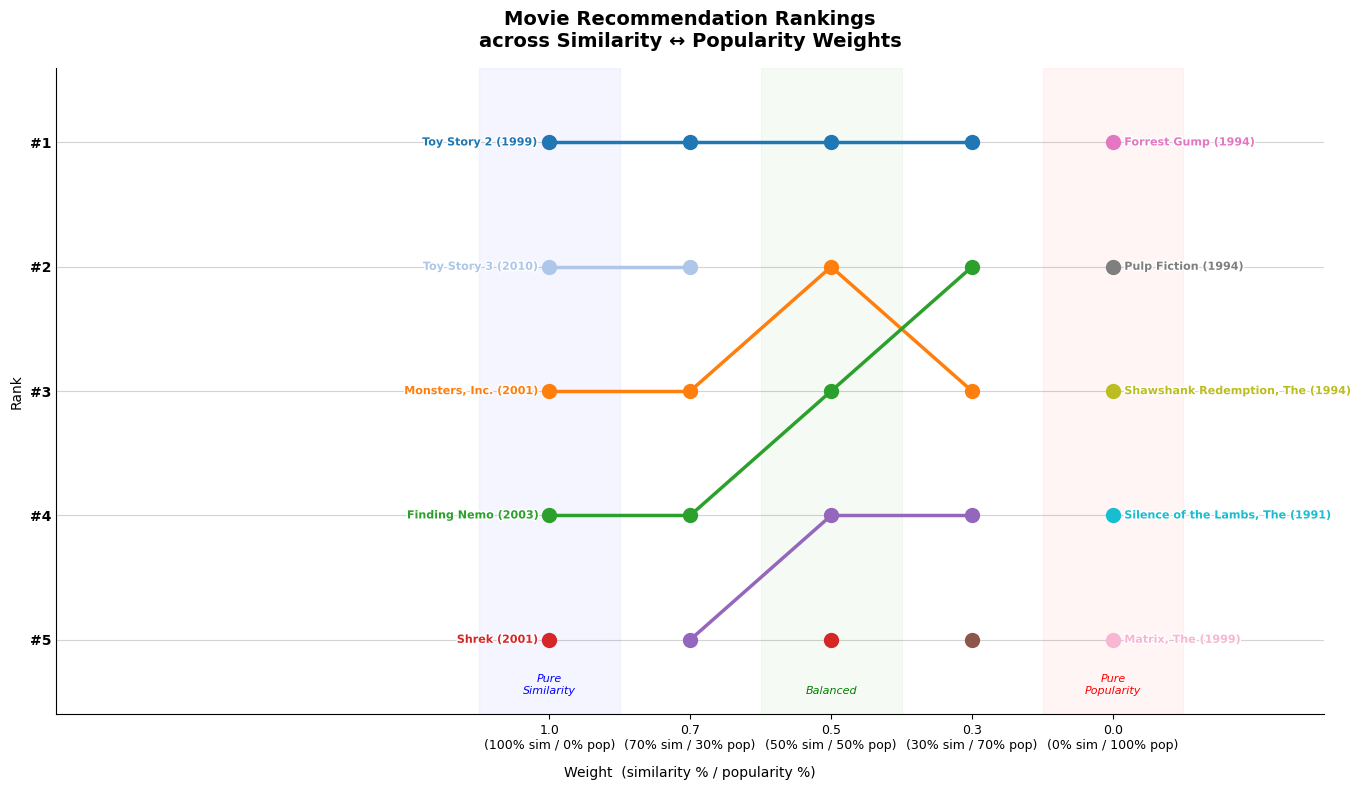

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np

# ── Data ──────────────────────────────────────────────────────────────────────
weights = [1.0, 0.7, 0.5, 0.3, 0.0]
weight_labels = [
    "1.0\n(100% sim / 0% pop)",
    "0.7\n(70% sim / 30% pop)",
    "0.5\n(50% sim / 50% pop)",
    "0.3\n(30% sim / 70% pop)",
    "0.0\n(0% sim / 100% pop)",
]

rankings = {
    "Toy Story 2 (1999)":              [1, 1, 1, 1, None],
    "Toy Story 3 (2010)":              [2, 2, None, None, None],
    "Monsters, Inc. (2001)":           [3, 3, 2, 3, None],
    "Finding Nemo (2003)":             [4, 4, 3, 2, None],
    "Shrek (2001)":                    [5, None, 5, None, None],
    "Incredibles, The (2004)":         [None, 5, 4, 4, None],
    "Lion King, The (1994)":           [None, None, None, 5, None],
    "Forrest Gump (1994)":             [None, None, None, None, 1],
    "Pulp Fiction (1994)":             [None, None, None, None, 2],
    "Shawshank Redemption, The (1994)":[None, None, None, None, 3],
    "Silence of the Lambs, The (1991)":[None, None, None, None, 4],
    "Matrix, The (1999)":              [None, None, None, None, 5],
}

# ── Color palette ─────────────────────────────────────────────────────────────
colors = {
    "Toy Story 2 (1999)":               "#1f77b4",
    "Toy Story 3 (2010)":               "#aec7e8",
    "Monsters, Inc. (2001)":            "#ff7f0e",
    "Finding Nemo (2003)":              "#2ca02c",
    "Shrek (2001)":                     "#d62728",
    "Incredibles, The (2004)":          "#9467bd",
    "Lion King, The (1994)":            "#8c564b",
    "Forrest Gump (1994)":              "#e377c2",
    "Pulp Fiction (1994)":              "#7f7f7f",
    "Shawshank Redemption, The (1994)": "#bcbd22",
    "Silence of the Lambs, The (1991)": "#17becf",
    "Matrix, The (1999)":               "#f7b6d2",
}

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(weights))

for movie, ranks in rankings.items():
    color = colors[movie]

    # collect segments where both endpoints are not None
    for i in range(len(ranks) - 1):
        if ranks[i] is not None and ranks[i + 1] is not None:
            ax.plot(
                [x[i], x[i + 1]],
                [ranks[i], ranks[i + 1]],
                color=color,
                linewidth=2.5,
                solid_capstyle="round",
            )

    # dots & labels at each valid rank
    for i, rank in enumerate(ranks):
        if rank is not None:
            ax.scatter(x[i], rank, color=color, s=100, zorder=5)

            # label on the LEFT side of weight=1.0
            if i == 0:
                ax.text(
                    x[i] - 0.08, rank,
                    movie,
                    ha="right", va="center",
                    fontsize=8, color=color,
                    fontweight="bold",
                    path_effects=[pe.withStroke(linewidth=2, foreground="white")],
                )
            # label on the RIGHT side of weight=0.0
            if i == len(ranks) - 1:
                ax.text(
                    x[i] + 0.08, rank,
                    movie,
                    ha="left", va="center",
                    fontsize=8, color=color,
                    fontweight="bold",
                    path_effects=[pe.withStroke(linewidth=2, foreground="white")],
                )

# ── Background shading ────────────────────────────────────────────────────────
ax.axvspan(-0.5,  0.5, alpha=0.04, color="blue",  label="Similarity zone")
ax.axvspan( 3.5,  4.5, alpha=0.04, color="red",   label="Popularity zone")
ax.axvspan( 1.5,  2.5, alpha=0.04, color="green", label="Balanced zone")

# ── Axes formatting ───────────────────────────────────────────────────────────
ax.set_xlim(-3.5, 5.5)
ax.set_ylim(5.6, 0.4)                        # rank 1 at top
ax.set_xticks(x)
ax.set_xticklabels(weight_labels, fontsize=9)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(["#1", "#2", "#3", "#4", "#5"], fontsize=10, fontweight="bold")
ax.yaxis.set_tick_params(length=0)

# Horizontal grid lines
for rank in [1, 2, 3, 4, 5]:
    ax.axhline(rank, color="lightgrey", linewidth=0.8, zorder=0)

ax.set_title(
    "Movie Recommendation Rankings\nacross Similarity ↔ Popularity Weights",
    fontsize=14, fontweight="bold", pad=15,
)
ax.set_xlabel("Weight  (similarity % / popularity %)", fontsize=10, labelpad=10)
ax.set_ylabel("Rank", fontsize=10)

# Annotate zones
for xpos, label, col in [
    (0,   "Pure\nSimilarity", "blue"),
    (2,   "Balanced",         "green"),
    (4,   "Pure\nPopularity", "red"),
]:
    ax.text(xpos, 5.45, label, ha="center", va="bottom",
            fontsize=8, color=col, style="italic")

ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("ranking_bump_chart.png", dpi=150, bbox_inches="tight")
plt.show()